# 01_returns_basics.ipynb

## Goal
Understand how to move from raw prices to returns, and why quants usually model returns instead of prices.

## Questions
- What is the difference between price changes, simple returns, and log returns?
- How do returns compound over time?
- Why are returns more suitable than prices for modeling?
- Are returns more stationary than prices?

In [82]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

TICKER = "DIS"
START_PERIOD = "3mo"

disney = yf.Ticker(TICKER)
disney_data = disney.history(period=START_PERIOD)

disney_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-01-15 00:00:00-05:00,113.709999,114.110001,112.169998,113.410004,7958500,0.0,0.0
2026-01-16 00:00:00-05:00,113.199997,113.849998,111.120003,111.199997,12049600,0.0,0.0
2026-01-20 00:00:00-05:00,109.660004,111.089996,108.800003,110.339996,9818200,0.0,0.0
2026-01-21 00:00:00-05:00,110.570000,113.250000,110.500000,113.190002,10041400,0.0,0.0
2026-01-22 00:00:00-05:00,113.169998,114.290001,112.169998,113.209999,12437700,0.0,0.0


We use the daily close price as the reference series for daily returns. In practice, adjusted close is preferred when available because it accounts for dividends and splits.

In [83]:
disney_prices = disney_data[["Close"]].rename(columns={"Close": "price"}).copy()

## Summary table

| Quantity | Formula |
|---|---|
| Price | $P_t$ |
| Absolute change | $P_t - P_{t-1}$ |
| Simple return | $\frac{P_t - P_{t-1}}{P_{t-1}}$ |
| Percentage simple return | $100 \times \frac{P_t - P_{t-1}}{P_{t-1}}$ |
| Log return | $\log\left(\frac{P_t}{P_{t-1}}\right)$ |
| Cumulative return | $\prod_{t=1}^{T}(1+r_t)-1$ |

### Notes

- **Absolute change** is measured in price units.
- **Simple return** is a unit-free relative change.
- **Percentage simple return** is the simple return multiplied by 100.
- **Log return** is useful because log returns add across time.
- **Cumulative return** is obtained by compounding one-period returns, not by adding simple returns.

In [ ]:
disney_prices["prev_price"] = disney_prices["price"].shift(1)
disney_prices["abs_change"] = disney_prices["price"].diff()
disney_prices["simple_return"] = disney_prices["price"].pct_change()
disney_prices["simple_return_pct"] = 100 * disney_prices["simple_return"]
disney_prices["log_return"] = np.log(disney_prices["price"] / disney_prices["prev_price"])

disney_prices["cumulative_return_from_simple"] = (1 + disney_prices["simple_return"]).cumprod() - 1
disney_prices["cumulative_log_return"] = disney_prices["log_return"].cumsum()
disney_prices["cumulative_return_from_log"] = np.exp(disney_prices["cumulative_log_return"]) - 1

disney_prices = disney_prices.dropna()

disney_prices.head()

,price,prev_price,abs_change,simple_return,percentage_simple_return,log_return
Date,,,,,,
2026-01-16 00:00:00-05:00,111.199997,113.410004,-2.210007,-1.019487,-101.948688,-0.019679
2026-01-20 00:00:00-05:00,110.339996,111.199997,-0.860001,-1.007734,-100.773382,-0.007764
2026-01-21 00:00:00-05:00,113.190002,110.339996,2.850006,-0.974171,-97.417069,0.025501
2026-01-22 00:00:00-05:00,113.209999,113.190002,0.019997,-0.999823,-99.982334,0.000177
2026-01-23 00:00:00-05:00,110.980003,113.209999,-2.229996,-1.019698,-101.969787,-0.019894


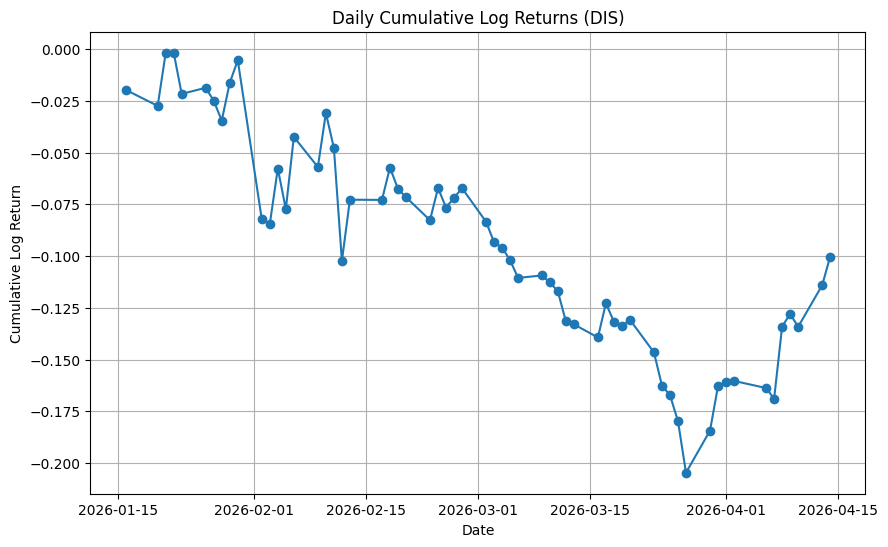

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(disney_prices.index, disney_prices["cumulative_return_from_simple"], marker="o", linestyle="-", label="From simple returns")
plt.plot(disney_prices.index, disney_prices["cumulative_return_from_log"], linestyle="--", label="From log returns")
plt.title(f"Cumulative Returns ({TICKER})")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.show()

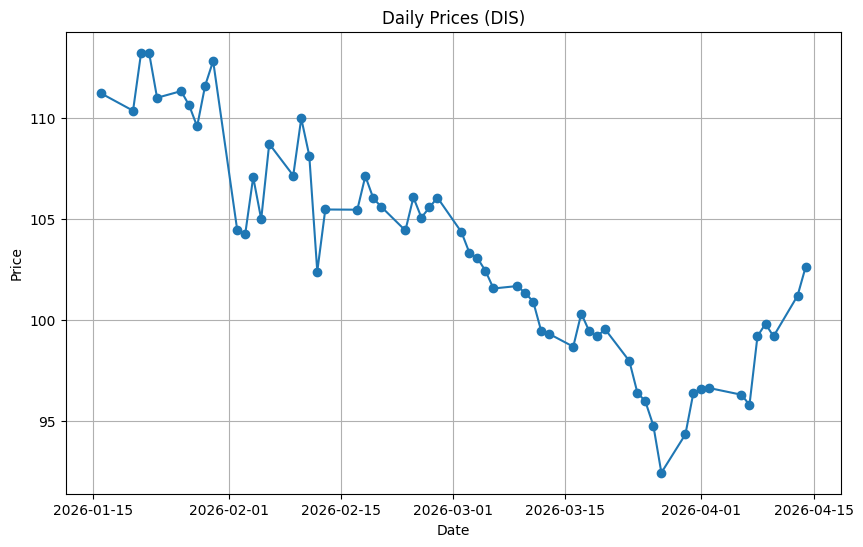

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(disney_prices.index, disney_prices["price"],marker='o',linestyle="-")
plt.title(f"Daily Prices ({TICKER})")
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

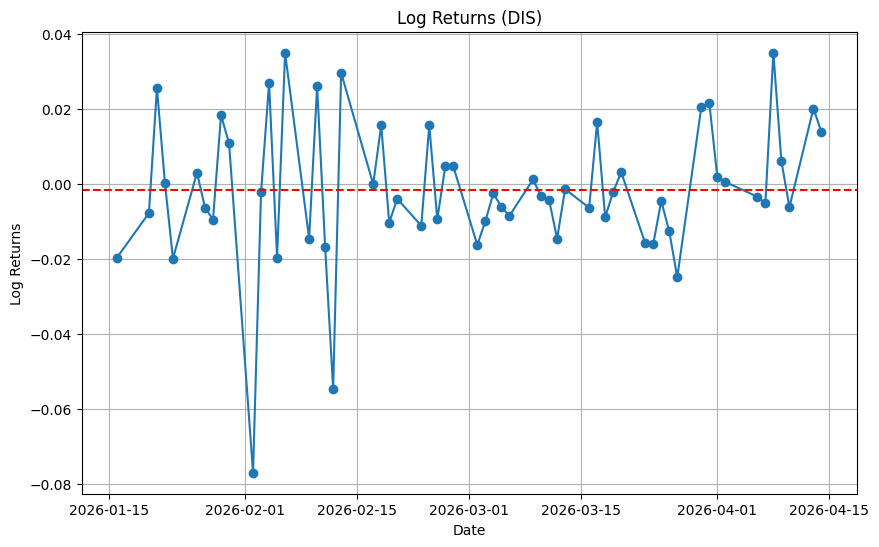

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(disney_prices.index, disney_prices["log_return"], marker="o", linestyle="-", label="Log return")
plt.title(f"Log Returns ({TICKER})")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.axhline(disney_prices["log_return"].mean(), color="red", linestyle="--", label="Mean")
plt.grid(True)
plt.legend()
plt.show()

In [81]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    adf_stat, p_value, used_lag, n_obs, crit_values, icbest = adfuller(series.dropna())
    
    print(f"ADF test on {name}")
    print(f"ADF statistic: {adf_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("Critical values:")
    for key, value in crit_values.items():
        print(f"  {key}: {value:.4f}")
    
    if p_value < 0.05:
        print(f"The {name} series looks stationary.")
    else:
        print(f"The {name} series does NOT look stationary.")
    print("\n" + "-" * 40 + "\n")

adf_test(disney_prices["price"], "PRICE")
adf_test(disney_prices["log_return"], "LOG RETURN")
adf_test(disney_prices["simple_return"], "SIMPLE RETURN")

ADF test on PRICE
ADF statistic: -1.5856
p-value: 0.4908
Critical values:
  1%: -3.5485
  5%: -2.9128
  10%: -2.5941
The PRICE series does NOT look stationary.

----------------------------------------

ADF test on LOG RETURN
ADF statistic: -9.0600
p-value: 0.0000
Critical values:
  1%: -3.5464
  5%: -2.9119
  10%: -2.5937
The LOG RETURN series looks stationary.

----------------------------------------

ADF test on SIMPLE RETURN
ADF statistic: -9.0844
p-value: 0.0000
Critical values:
  1%: -3.5464
  5%: -2.9119
  10%: -2.5937
The SIMPLE RETURN series looks stationary.

----------------------------------------

